## Image Augmentation

Cats v Dogs 로 다음처럼 모델링 하고, 학습시켜본다.

4 convolutional layers with 32, 64, 128 and 128 convolutions

train for 100 epochs

- 실 세계의 이미지 데이터는 어떻게 생성했냐?
- 현업에서는 데이터가 스토리지 서비스에 저장
- 저장된 데이터에 이미지를 레이블링해야함.

# 데이터 준비

In [1]:
# warning 무시
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf

# 새로운 초기 가중치로 처음부터 다시 학습
tf.keras.backend.clear_session()

I0000 00:00:1788244458.640744   69985 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788244458.685872   69985 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788244460.322875   69985 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import tensorflow as tf
# TensorFlow가 GPU 메모리를 처음부터 크게 선점하지 않고, 필요한 만큼 점진적으로 사용하도록 설정
gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

- 데이터 다운로드: https://drive.google.com/file/d/1wr4e_7P2d4ICN11ecNb8aqhbakD4ahK6/view?usp=sharing

In [4]:
import os, zipfile, pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [5]:
# 윈도우 환경
import os
import zipfile
import urllib.request

In [6]:
# 압축을 풀 위치
data_path = "./datas_dnn"
os.makedirs(data_path, exist_ok=True)
extract_root = pathlib.Path(data_path)

In [7]:
# uv add gdown

In [8]:
# import gdown  
# # 데이터의 위치
# url = "https://drive.google.com/uc?id=1wr4e_7P2d4ICN11ecNb8aqhbakD4ahK6"
# file_id = "1wr4e_7P2d4ICN11ecNb8aqhbakD4ahK6"
# output = "datas_dnn/cats_and_dogs_filtered.zip" # 저장 위치 및 저장할 파일 이름
# zip_path = gdown.download(id=file_id, output=output, quiet=False)

In [9]:
# 압축풀기
zip_path = "datas_dnn/cats_and_dogs_filtered.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_file:
    zip_file.extractall(extract_root)

- 현실 데이터는 이미지 사이즈가 제각각임
- 폴더명이 레이블 이름

In [10]:
IMG_SIZE = 150
IMAGE_SHAPE= (IMG_SIZE, IMG_SIZE, 3)

In [11]:
BATCH_SIZE = 20

In [12]:
SEED = 1337

In [13]:
BASE_DIR = extract_root / 'cats_and_dogs_filtered'
train_dir  = BASE_DIR / 'train'
test_dir = BASE_DIR / 'validation'

In [14]:
train_dir

PosixPath('datas_dnn/cats_and_dogs_filtered/train')

In [15]:
test_dir

PosixPath('datas_dnn/cats_and_dogs_filtered/validation')

In [16]:
# 학습 데이터 셋만들기
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,            # 학습 데이터 위치
    image_size = (IMG_SIZE, IMG_SIZE), # 이미지 사이즈
    batch_size = BATCH_SIZE,           # batch 크기
    shuffle=True,                      # shuffle
    seed=SEED
)

Found 2000 files belonging to 2 classes.


I0000 00:00:1788244463.997481   69985 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [17]:
# 테스트 데이터셋 만들기
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = (IMG_SIZE, IMG_SIZE) ,
    batch_size = BATCH_SIZE,
    shuffle=True,
)

Found 1000 files belonging to 2 classes.


In [18]:
# target 값 가져오기(폴더 이름)
class_names = train_ds.class_names

In [19]:
class_names

['cats', 'dogs']

# 성능 최적화를 위한 코드(GPU 사용시)
- 다음 배치를 백그라운드에서 미리 준비하라는 코드 작성
- 학습 효과를 높이기 위해
- 데이터 증강, 데이터 플립, 

In [20]:
# TensorFlow가 prefetch 버퍼 크기를 자동으로 조절해주는 옵션
AUTOTUNE = tf.data.AUTOTUNE

In [21]:
# 학습 중 다음 배치(batch)를 백그라운드에서 미리 준비(학습 속도 빨라짐)
train_ds = train_ds.prefetch(AUTOTUNE)

In [22]:
# 검증(validation) 데이터도 동일하게 최적화하는 과정
test_ds = test_ds.prefetch(AUTOTUNE)

## 데이터 증강

In [23]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1)
    ],
    name = 'data_augmentation',
)

# 학습 모델 만들기

## 모델 설계

In [24]:
from tensorflow import keras
from tensorflow.keras import layers, Sequential

In [25]:
def build_model(input_shape):
    return Sequential(
        [
            layers.Input(shape=input_shape),
            data_augmentation,  # 데이터 증강
            layers.Rescaling(1.0/255.0),  # 스케일링
            layers.Conv2D(32, 3, activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Conv2D(64, 3, activation='relu'),
            layers.MaxPooling2D(2,2),
            layers.Conv2D(128, 3, activation='relu'), 
            layers.MaxPooling2D(2,2),

            # 출력층 전에 1차원으로 변경해야함.
            layers.Flatten(),
            layers.Dense(512, activation='relu'),
            layers.Dropout(0.2), 
            layers.Dense(2, activation='softmax')  # 출력층 2개
        ],
        name="simple_cnn",
    )
    

In [26]:
model = build_model(IMAGE_SHAPE)

In [27]:
model.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,690 (72.61 MB)

 Trainable params: 19,034,690 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer=keras.optimizers.Adam(), 
            loss= keras.losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

In [29]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=5, # 시간 많이 걸림
                                           # patience=3,
                                           restore_best_weights=True)

## 모델 학습

In [30]:
history = model.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=100, 
    callbacks=[early_stop]
)

Epoch 1/100


I0000 00:00:1788244468.293109   70157 cuda_dnn.cc:461] Loaded cuDNN version 92501


100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.5075 - loss: 0.7772 - val_accuracy: 0.5400 - val_loss: 0.6930
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5115 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5210 - loss: 0.6919 - val_accuracy: 0.5510 - val_loss: 0.6903
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5130 - loss: 0.7009 - val_accuracy: 0.5360 - val_loss: 0.6902
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.4880 - loss: 0.6939 - val_accuracy: 0.5120 - val_loss: 0.6925
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5210 - loss: 0.6910 - val_accuracy: 0.5380 - val_loss: 0.6904
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4995 - loss: 0.6929 - val_accuracy: 0.5500 - val_loss: 0.6876
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5210 - loss: 0.6909 - val_accuracy

# 모델 평가

In [31]:
model.evaluate(test_ds)

 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5000 - loss: 0.6895

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5500 - loss: 0.6876


[0.6875907778739929, 0.550000011920929]

In [32]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

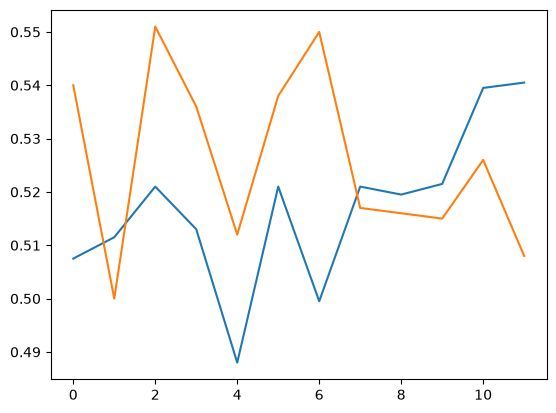

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

# 모델 저장하기

In [34]:
import os
os.makedirs('models', exist_ok=True)
model.save('models/my_dog_cat_model.keras')

# 일반화

In [35]:
# 학습한 모델 불러오기
model = tf.keras.models.load_model("models/my_dog_cat_model.keras")

# 클래스 이름
class_names = ["cat", "dog"]

## 이미지 확인

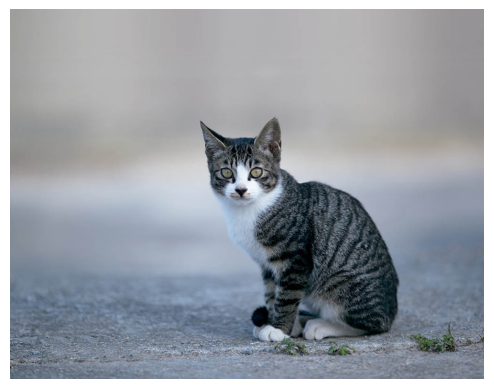

In [36]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 예측하고 싶은 이미지 경로
img_path = "images/cat.jpg"

img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')   # 축 제거 (선택)
plt.show()

In [37]:
import numpy as np
# 1) 이미지 로딩
img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

# 2) 배열로 변환
img_array = tf.keras.utils.img_to_array(img)

# 3) 0~1 범위 일반화
img_array = img_array / 255.0

# 4) 배치 차원 추가 (1, 150,150,3)
img_array = np.expand_dims(img_array, axis=0)

In [38]:
import tensorflow as tf
import numpy as np

IMG_SIZE = 150

def load_and_preprocess_image(img_path):
    # 1) 이미지 로드
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    
    # 2) 배열로 변환
    img_array = tf.keras.utils.img_to_array(img)
    
    # 3) 0~1 범위 일반화
    img_array = img_array / 255.0
    
    # 4) 배치 차원 추가 (1, 150,150,3)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array


def predict_image(model, img_path, class_names):
    img = load_and_preprocess_image(img_path)
    pred = model.predict(img)
    print(pred)
    # 클래스 index
    pred_idx = np.argmax(pred, axis=1)[0]
    print(pred_idx)
    pred_class = class_names[pred_idx]
    pred_prob = np.max(pred)

    print(f"예측 클래스: {pred_class}")
    print(f"확률: {pred_prob:.4f}")


In [39]:
# 학습한 모델 불러오기
model = tf.keras.models.load_model("models/my_dog_cat_model.keras")

# 클래스 이름
class_names = ["cat", "dog"]

# 예측하고 싶은 이미지 경로
img_path = "images/cat.jpg"

predict_image(model, img_path, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
[[9.9928397e-01 7.1609556e-04]]
0
예측 클래스: cat
확률: 0.9993
